<a href="https://colab.research.google.com/github/afreenzaib15/FGG/blob/main/FGG_Meta_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('FGG.csv')
df['Years_Cold'] = df['Year_Resolved'] - df['Year_Found']

print("--- FGG Meta-Analysis Stats ---")
print(f"Total Cases Analyzed: {len(df)}")
print(f"Average Years Cold: {df['Years_Cold'].mean():.1f}")
print(f"Oldest Case Resolved: {df['Years_Cold'].max()} years")

FileNotFoundError: [Errno 2] No such file or directory: 'FGG.csv'

In [ ]:
import os
print(os.listdir('/content'))

['.config', 'sample_data']


In [ ]:
from google.colab import files

print("Please select 'FGG.csv' to upload:")
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Please select 'FGG.csv' to upload:


Saving FGG.csv to FGG.csv
User uploaded file "FGG.csv" with length 628 bytes


After successfully uploading, you should see a confirmation message. Now, the `FGG.csv` file should be available in your Colab environment.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('FGG.csv')
# Convert year columns to numeric, coercing errors to NaN
df['YEAR_RESOLVED'] = pd.to_numeric(df['YEAR_RESOLVED'], errors='coerce')
df['YEAR_FOUND'] = pd.to_numeric(df['YEAR_FOUND'], errors='coerce')

# Drop rows where year conversion resulted in NaN (if any)
df.dropna(subset=['YEAR_RESOLVED', 'YEAR_FOUND'], inplace=True)

df['Years_Cold'] = df['YEAR_RESOLVED'] - df['YEAR_FOUND']

print("--- FGG Meta-Analysis Stats ---")
print(f"Total Cases Analyzed: {len(df)}")
print(f"Average Years Cold: {df['Years_Cold'].mean():.1f}")
print(f"Oldest Case Resolved: {df['Years_Cold'].max()} years")

--- FGG Meta-Analysis Stats ---
Total Cases Analyzed: 3
Average Years Cold: 38.7
Oldest Case Resolved: 46.0 years


### Distribution of Years Cases Remain Cold

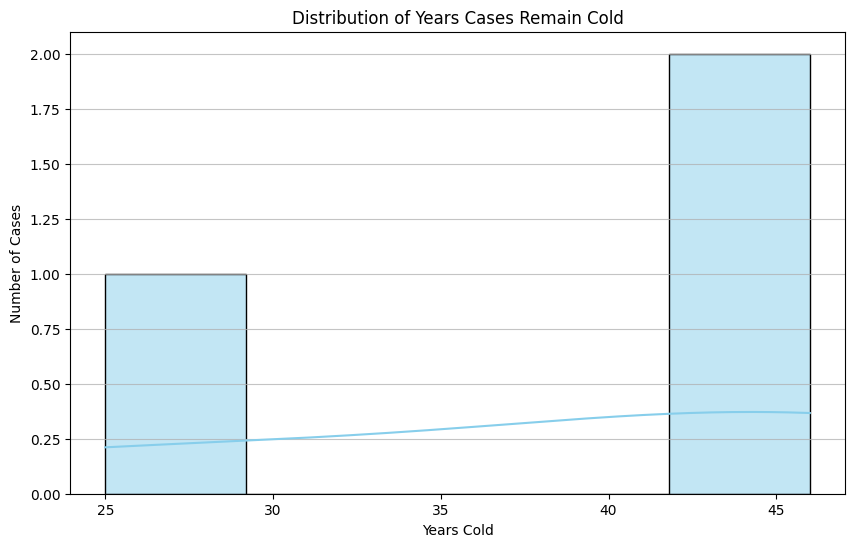

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Years_Cold'], bins=5, kde=True, color='skyblue')
plt.title('Distribution of Years Cases Remain Cold')
plt.xlabel('Years Cold')
plt.ylabel('Number of Cases')
plt.grid(axis='y', alpha=0.75)
plt.show()

### Defining 'Cold Case Thaw' and 'Resolution Velocity'

- **Cold Case Thaw**: This metric will be represented directly by the `Years_Cold` column, which signifies the duration a case remained unresolved. A lower `Years_Cold` indicates a quicker 'thaw' or resolution.

- **Resolution Velocity**: This metric will be calculated as the inverse of `Years_Cold`. A higher 'Resolution Velocity' indicates that the case was resolved more quickly. To handle cases where `Years_Cold` might be zero (meaning the case was resolved in the same year it was found), the 'Resolution Velocity' will be set to `NaN` to avoid division by zero.

In [ ]:
import numpy as np

# 'Cold Case Thaw' is already represented by 'Years_Cold'
# Calculate 'Resolution Velocity'
df['Resolution_Velocity'] = np.where(
    df['Years_Cold'] == 0,
    np.nan, # Assign NaN if Years_Cold is 0 to avoid division by zero
    1 / df['Years_Cold']
)

print("--- Updated FGG Meta-Analysis with Resolution Velocity ---")
display(df[['CASE_NAME', 'Years_Cold', 'Resolution_Velocity']].head())

--- Updated FGG Meta-Analysis with Resolution Velocity ---


,CASE_NAME,Years_Cold,Resolution_Velocity
1,John Charles City Doe,46.0,0.021739
2,Greenbelt John Doe,45.0,0.022222
7,Bear Brook Jane Doe,25.0,0.040000


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


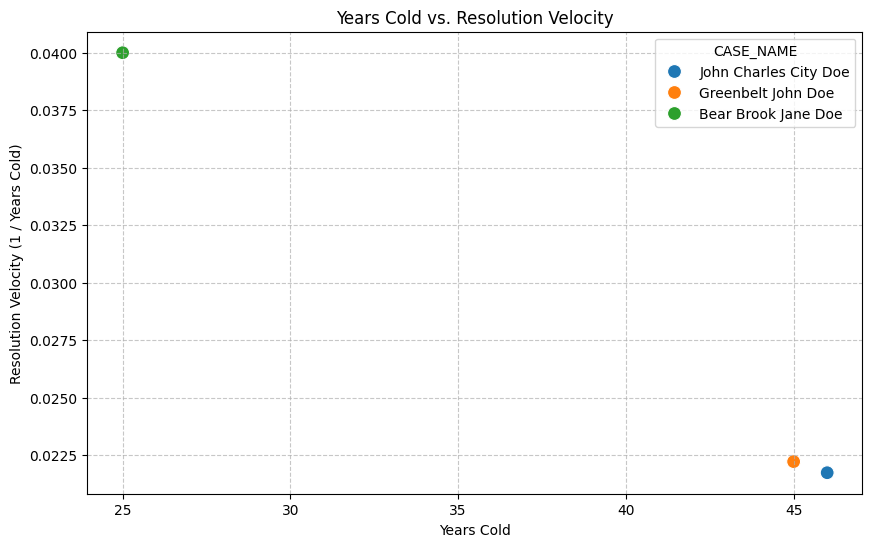

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Years_Cold', y='Resolution_Velocity', data=df, s=100, hue='CASE_NAME') # 's' for size, 'hue' to differentiate points
plt.title('Years Cold vs. Resolution Velocity')
plt.xlabel('Years Cold')
plt.ylabel('Resolution Velocity (1 / Years Cold)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [12]:
igg_years_cold_mean = df.groupby('IGG_Used')['Years_Cold'].mean()
display(igg_years_cold_mean)

,Years_Cold
IGG_Used,
0,46.0
1,35.0


In [13]:
median_years_cold = df['Years_Cold'].median()
std_years_cold = df['Years_Cold'].std()

print(f"Median Years Cold: {median_years_cold:.2f}")
print(f"Standard Deviation of Years Cold: {std_years_cold:.2f}")

Median Years Cold: 45.00
Standard Deviation of Years Cold: 11.85
